<a href="https://colab.research.google.com/github/feridehmedovv200/OIBSIP/blob/main/L2_Task2_Wine_Quality_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== DATASET OVERVIEW ===
Dataset Shape: (1143, 13)

Missing Values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

Class Distribution (Raw Quality Scores):
quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64


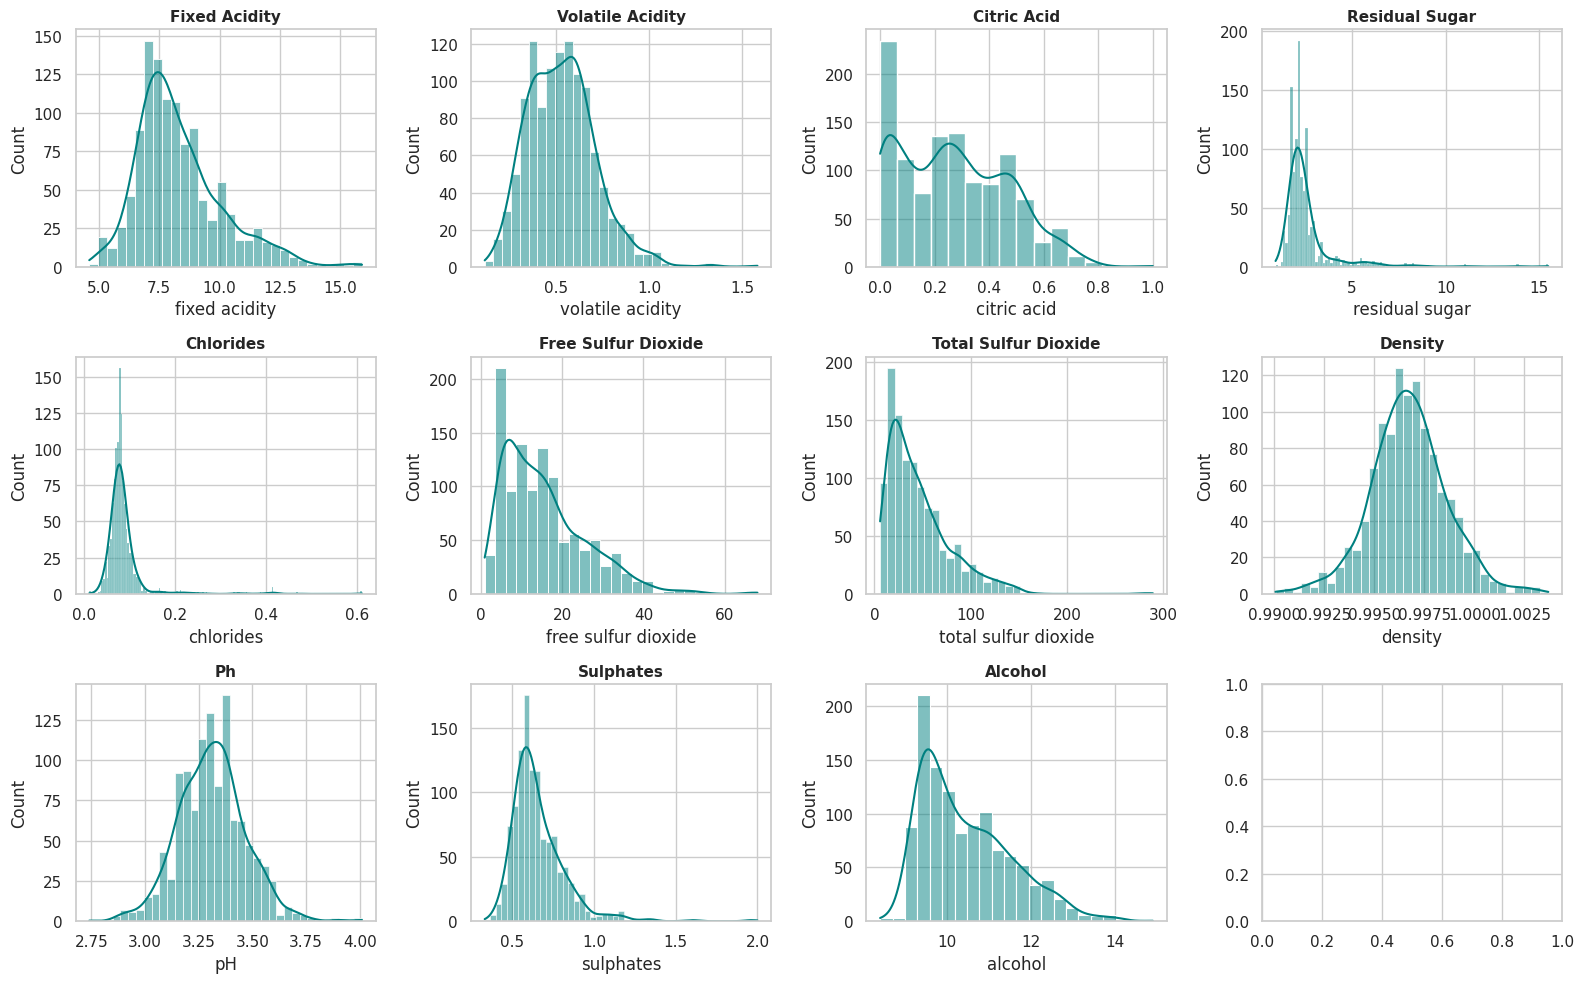

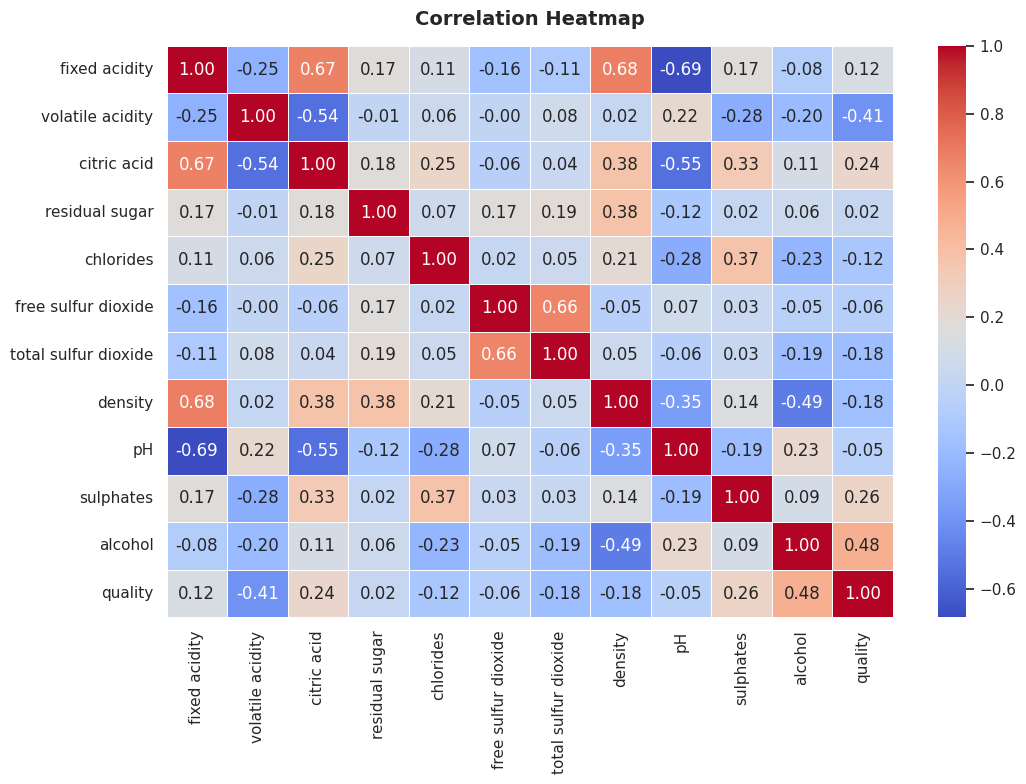


==================== Random Forest ====================
Accuracy: 0.9214
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.97      0.96       197
           1       0.79      0.59      0.68        32

    accuracy                           0.92       229
   macro avg       0.86      0.78      0.82       229
weighted avg       0.92      0.92      0.92       229


==================== SGD Classifier ====================
Accuracy: 0.8821
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.92      0.93       197
           1       0.57      0.62      0.60        32

    accuracy                           0.88       229
   macro avg       0.75      0.77      0.76       229
weighted avg       0.89      0.88      0.88       229


==================== Support Vector Classifier (SVC) ====================
Accuracy: 0.8996
Classification Report:
               precision    recall

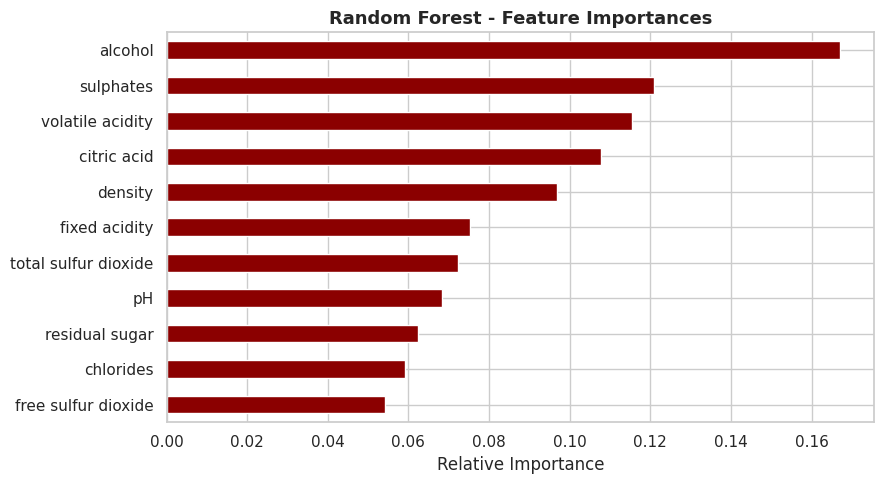

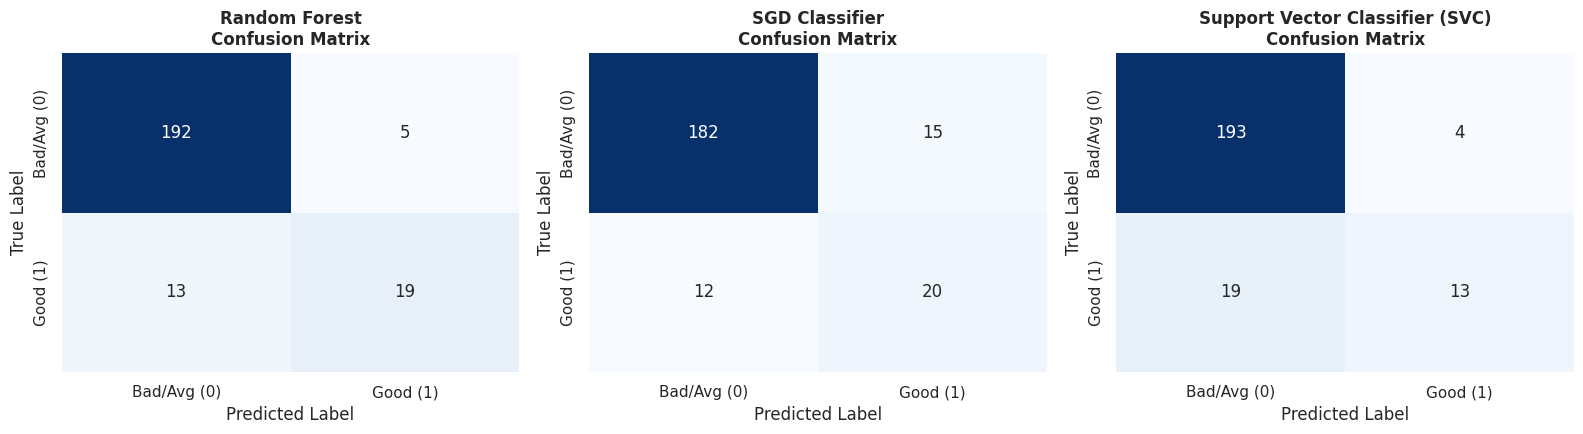

In [1]:
# ==============================================================================
# TASK 2 · Wine Quality Prediction
# Tech Stack: Python, pandas, numpy, scikit-learn, seaborn, matplotlib
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, precision_recall_fscore_support

# Visual style configuration
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "sans-serif"


# 1. LOAD DATASET & INSPECT STRUCTURE
# ------------------------------------------------------------------------------
df = pd.read_csv('WineQT.csv')

print("=== DATASET OVERVIEW ===")
print(f"Dataset Shape: {df.shape}")
print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Distribution (Raw Quality Scores):")
print(df['quality'].value_counts().sort_index())


# 2. EXPLORATORY DATA ANALYSIS (EDA)
# ------------------------------------------------------------------------------
# Drop unnecessary 'Id' column if present
if 'Id' in df.columns:
    df = df.drop(columns=['Id'])

features = [col for col in df.columns if col != 'quality']

# Distribution plots for all chemical features
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=300)
plt.show()

# Correlation Heatmap
plt.figure(figsize=(11, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=300)
plt.show()


# 3. FEATURE ENGINEERING & TRAIN/TEST SPLIT
# ------------------------------------------------------------------------------
# Binning quality scores into binary classification:
# Good Wine (1): quality >= 7
# Bad / Average Wine (0): quality < 7
df['target'] = (df['quality'] >= 7).astype(int)

X = df.drop(columns=['quality', 'target'])
y = df['target']

# Train/Test Split with Stratification to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling (Crucial for SGD and SVC)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# 4. MODEL TRAINING & EVALUATION
# ------------------------------------------------------------------------------
models = {
    'Random Forest': (RandomForestClassifier(random_state=42), X_train, X_test),
    'SGD Classifier': (SGDClassifier(random_state=42), X_train_scaled, X_test_scaled),
    'Support Vector Classifier (SVC)': (SVC(random_state=42), X_train_scaled, X_test_scaled)
}

results_list = []
confusion_matrices = {}

for name, (model, train_x, test_x) in models.items():
    # Fit model
    model.fit(train_x, y_train)
    y_pred = model.predict(test_x)

    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary', pos_label=1)
    weighted_f1 = precision_recall_fscore_support(y_test, y_pred, average='weighted')[2]
    cm = confusion_matrix(y_test, y_pred)

    confusion_matrices[name] = cm

    results_list.append({
        'Model': name,
        'Accuracy': f"{acc:.4f}",
        'Precision (Class 1)': f"{prec:.4f}",
        'Recall (Class 1)': f"{rec:.4f}",
        'F1-Score (Class 1)': f"{f1:.4f}",
        'Weighted F1': f"{weighted_f1:.4f}"
    })

    print(f"\n==================== {name} ====================")
    print(f"Accuracy: {acc:.4f}")
    print("Classification Report:\n", classification_report(y_test, y_pred))


# 5. MODEL COMPARISON SUMMARY
# ------------------------------------------------------------------------------
comparison_df = pd.DataFrame(results_list)
print("\n=== COMPARISON TABLE ===")
print(comparison_df.to_string(index=False))


# 6. FEATURE IMPORTANCE CHART (RANDOM FOREST)
# ------------------------------------------------------------------------------
rf_model = models['Random Forest'][0]
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(9, 5))
importances.plot(kind='barh', color='darkred')
plt.title('Random Forest - Feature Importances', fontsize=13, fontweight='bold')
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=300)
plt.show()


# 7. CONFUSION MATRIX VISUALIZATION
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (name, cm) in zip(axes, confusion_matrices.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Bad/Avg (0)', 'Good (1)'],
                yticklabels=['Bad/Avg (0)', 'Good (1)'])
    ax.set_title(f'{name}\nConfusion Matrix', fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300)
plt.show()